<a href="https://colab.research.google.com/github/JacksonvBarbosa/datathon_fiap_postech/blob/eda_will/datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perguntas a serem respondidas

5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que
antecedem quedas de desempenho acadêmico ou de engajamento?
Resposta: **Embora não haja uma correlação direta imediata, observou-se que uma queda significativa no bem-estar psicossocial (IPS) em um ano (ex: 2023) precede uma queda no desempenho acadêmico (IDA) e no engajamento (IEG) no ano seguinte (2024).
Sinal de Alerta: A queda de 1,78 pontos no IPS médio entre 2022 e 2023 serviu como um 'aviso', antes mesmo das notas ou da participação caírem**
6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas
(IPP) confirmam ou contradizem a defasagem identificada pelo IAN?
Resposta: **Não ha correlação entre as duas metricas e quando vemos a serie temporial das duas correlação de 0,12 é considerada muito baixa, indicando que as avaliações psicopedagógicas (IPP) e o indicador de aprendizado/defasagem (IAN) medem dimensões diferentes e não variam de forma sincronizada. Além disso, os valores temporais confirmam que enquanto o IPP permaneceu estável (7,56 para 7,55), o IAN (defasagem) teve uma melhora de 7,24 para 7,68, mostrando que o desempenho reportado evoluiu independentemente da percepção psicopedagógica média**

7. Ponto de virada (IPV): Quais comportamentos - acadêmicos,
emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?
10. Efetividade do programa: Os indicadores mostram melhora
consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e
Topázio), confirmando o impacto real do programa?

In [ ]:
from logging import warning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px



#Carregando DF


In [ ]:
# Substitua pela sua URL Raw do
url = 'https://raw.githubusercontent.com/JacksonvBarbosa/datathon_fiap_postech/refs/heads/main/data/processed/base_de_dados_completo_eda.csv'

# Carregar o dataset

df = pd.read_csv(url)
df.head()

,data_referencia,ra,fase,turma,nome,ano_nasc,idade_22,gênero,ano_ingresso,instituição_de_ensino,...,ing,fase_ideal.1,destaque_ipv_1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo/inativo,ativo/inativo_1
0,2022-01-01,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,RA-61,5,B,Aluno-61,2007.0,15.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,RA-610,1,L,Aluno-610,2013.0,9.0,Menina,2022,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,RA-611,1,M,Aluno-611,2010.0,12.0,Menino,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,RA-612,1,M,Aluno-612,2012.0,10.0,Menina,2021,Escola Pública,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 64 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   data_referencia        3030 non-null   object 
 1   ra                     3030 non-null   object 
 2   fase                   3030 non-null   object 
 3   turma                  3030 non-null   object 
 4   nome                   860 non-null    object 
 5   ano_nasc               860 non-null    float64
 6   idade_22               860 non-null    float64
 7   gênero                 3030 non-null   object 
 8   ano_ingresso           3030 non-null   int64  
 9   instituição_de_ensino  3029 non-null   object 
 10  pedra_20               754 non-null    object 
 11  pedra_21               1061 non-null   object 
 12  pedra_22               1932 non-null   object 
 13  inde_22                1932 non-null   float64
 14  cg                     860 non-null    float64
 15  cf  

In [ ]:
df ['ian'].head()

,ian
0,5.0
1,10.0
2,10.0
3,5.0
4,5.0


In [ ]:
df1 = df['data_referencia'].count()
df1

np.int64(3030)

# Pergunta 1


In [ ]:
#níveis de IAN e defasagem

df1 = df.groupby(['defasagem'])['ian'].mean().reset_index().round(2).sort_values(by='defasagem', ascending=False)
df1

,defasagem,ian
8,3,10.0
7,2,10.0
6,1,10.0
5,0,10.0
4,-1,5.0
3,-2,5.0
2,-3,2.5
1,-4,2.5
0,-5,2.5


In [ ]:
#como IAN evolui ao longo dos anos

df1 = df.groupby(['data_referencia'])['ian'].mean().reset_index().round(2)
df1

,data_referencia,ian
0,2022-01-01,6.42
1,2023-01-01,7.24
2,2024-01-01,7.68


In [ ]:
#como IAN evolui ao longo dos anos e defasagem
df1 = df.groupby(['defasagem','data_referencia'])['ian'].mean().reset_index().round(2).sort_values(by='defasagem', ascending=False)
df1

,defasagem,data_referencia,ian
21,3,2024-01-01,10.0
19,2,2023-01-01,10.0
18,2,2022-01-01,10.0
20,2,2024-01-01,10.0
15,1,2022-01-01,10.0
17,1,2024-01-01,10.0
16,1,2023-01-01,10.0
14,0,2024-01-01,10.0
13,0,2023-01-01,10.0
12,0,2022-01-01,10.0


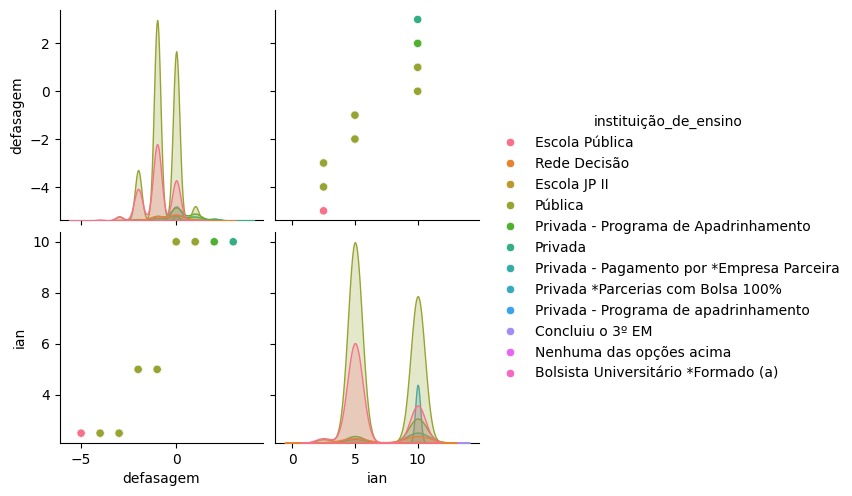

In [ ]:
df2 = df[['defasagem', "ian", 'instituição_de_ensino']]
sns.pairplot(df2, hue ='instituição_de_ensino')

In [ ]:
#níveis de IAN e defasagem

df1 = df.groupby(['ips'])['ida'].mean().reset_index().round(2).sort_values(by='ida', ascending=False)
df1

,ips,ida
53,9.38,8.46
0,2.50,8.10
39,7.20,7.86
12,4.39,7.81
44,8.10,7.62
32,6.57,7.58
55,9.40,7.51
22,5.64,7.50
52,8.80,7.19
7,3.77,7.13


In [ ]:
#níveis de IAN e defasagem

media_ips = df.groupby(['ips']).agg(
    desempenho_academico=('ida', 'mean'),
    engajamento=('ieg', 'mean'),
).reset_index().round(2).sort_values(by='ips', ascending=False)

media_ips




,ips,desempenho_academico,engajamento
56,10.00,5.80,8.60
55,9.40,7.51,9.14
53,9.38,8.46,9.03
54,9.38,6.26,8.01
52,8.80,7.19,8.15
50,8.76,5.77,7.56
51,8.76,5.82,8.48
49,8.75,4.17,8.50
47,8.14,6.30,8.31
48,8.14,7.13,8.70


In [ ]:

temporal_ips = df.groupby(['data_referencia']).agg(
    psicossociais=('ips', 'mean'),
    desempenho_academico=('ida', 'mean'),
    engajamento=('ieg', 'mean'),
).reset_index().round(2).sort_values(by='data_referencia', ascending=True)

temporal_ips




,data_referencia,psicossociais,desempenho_academico,engajamento
0,2022-01-01,6.90,6.09,7.89
1,2023-01-01,5.12,6.66,8.70
2,2024-01-01,6.83,6.35,7.37


In [ ]:
dados_usaveis=temporal_ips.set_index("data_referencia")
dados_usaveis.head()

,psicossociais,desempenho_academico,engajamento
data_referencia,,,
2022-01-01,6.90,6.09,7.89
2023-01-01,5.12,6.66,8.70
2024-01-01,6.83,6.35,7.37


<Axes: xlabel='data_referencia'>

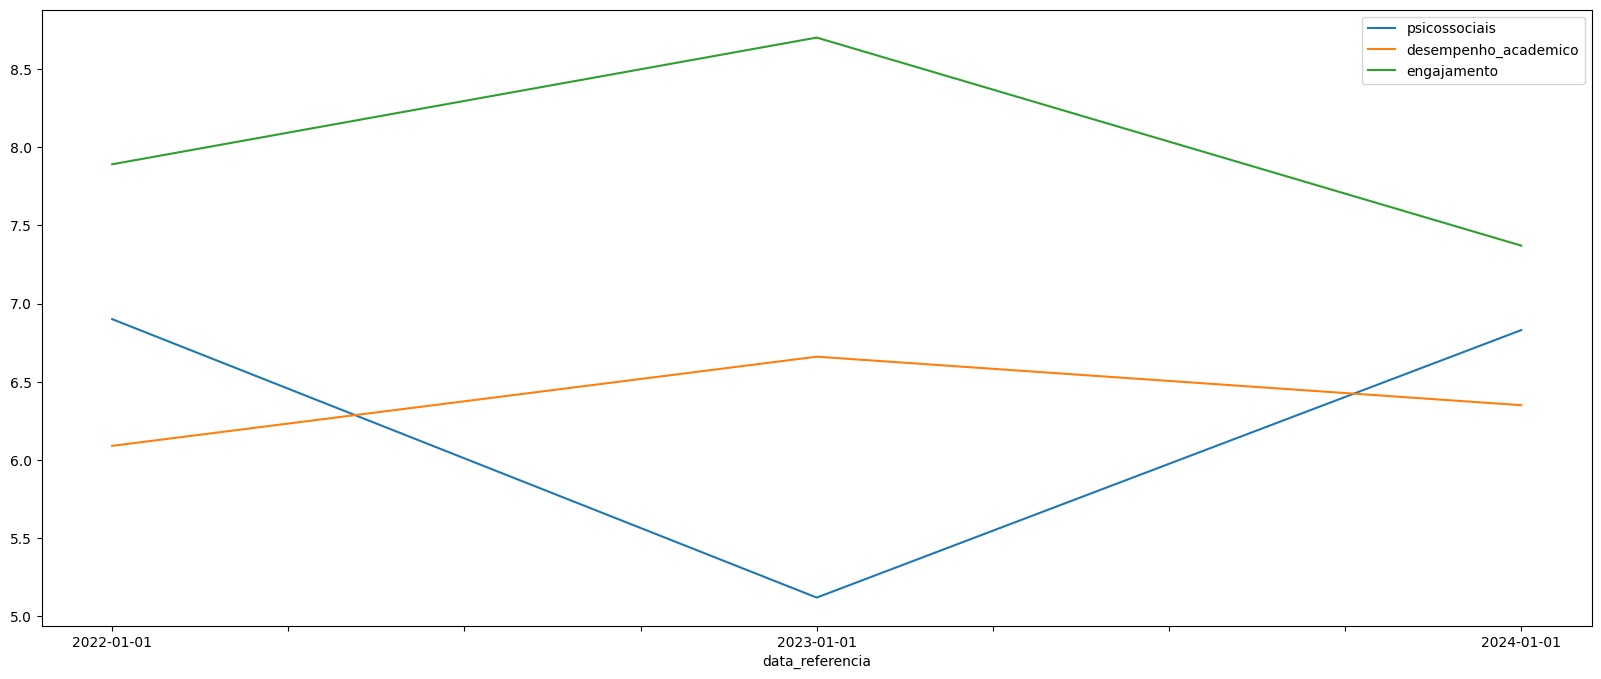

In [ ]:
dados_usaveis.plot (figsize=(20,8))

In [ ]:
df2 = df[['ips', "ida", 'ieg']]
df2.head()


,ieg,ida,ips
0,4.1,4.0,5.6
1,7.4,5.8,7.5
2,9.6,6.5,7.5
3,7.6,9.5,7.5
4,9.2,7.9,7.5


<Axes: >

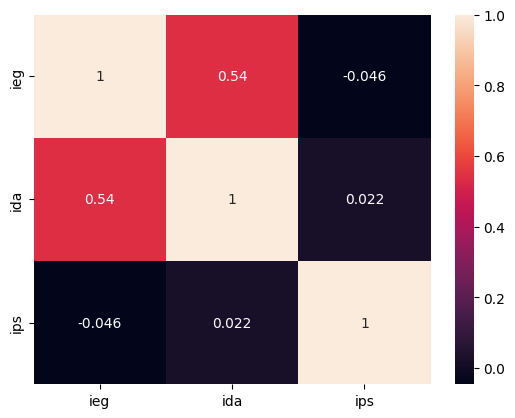

In [ ]:

df2_correl = df2.corr()
df2_correl

#plotando grafico correlação

sns.heatmap(df2_correl, annot=True)


In [ ]:

temporal_ipp = df.groupby(['data_referencia']).agg(
    psicopedagógicas=('ipp', 'mean'),
    defasagem=('ian', 'mean'),
).reset_index().round(2).sort_values(by='data_referencia', ascending=True)

temporal_ipp




,data_referencia,psicopedagógicas,defasagem
0,2022-01-01,NaN,6.42
1,2023-01-01,7.56,7.24
2,2024-01-01,7.55,7.68


<Axes: xlabel='data_referencia'>

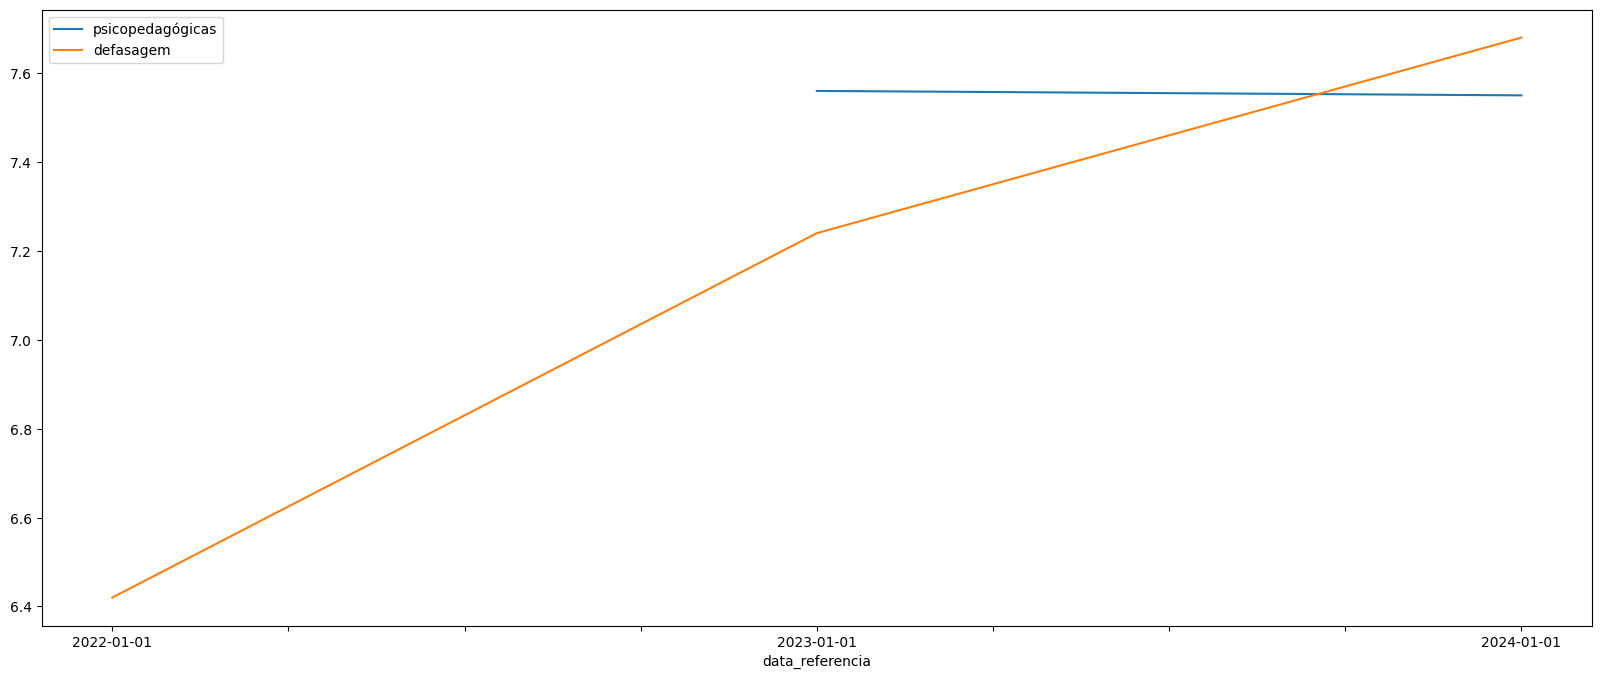

In [ ]:
temporal_ipp = temporal_ipp.set_index(["data_referencia"])
temporal_ipp.plot(figsize=(20,8))

In [ ]:
temporal_ipp

In [ ]:
ips_correl = df[['ipp', "ian"]].dropna()
ips_correl.head()


,ipp,ian
860,7.916667,5.0
861,7.916667,5.0
862,8.125000,10.0
863,8.333333,5.0
864,8.333333,5.0


<Axes: >

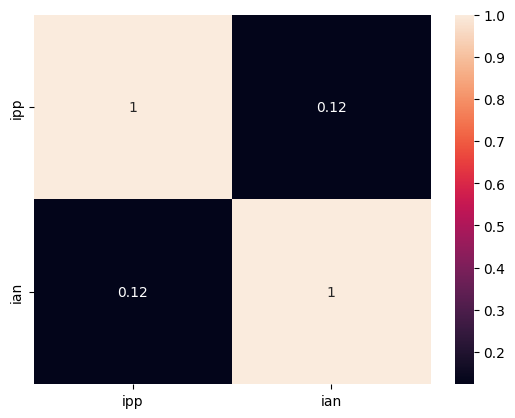

In [ ]:
ips_correl = ips_correl.corr()
sns.heatmap(ips_correl, annot=True)


In [ ]:
contegem_ipp = df[['ipp', "ian"]]
print(f'Quantidade de dados nulos: {contegem_ipp.isnull().sum().sum()}')

Quantidade de dados nulos: 1038


1. Métricas Acadêmicas
Estas métricas avaliam o desempenho técnico e a adequação escolar do aluno:
• IDA (Indicador de Desempenho Acadêmico): É a média das notas em Português, Matemática e Inglês. Existe uma forte correlação estatística entre o IDA e o sucesso geral do aluno (90% da variação do índice geral INDE é explicada pela combinação de IDA e engajamento).
• IAN (Indicador de Adequação de Nível): Avalia a defasagem idade-série. Alunos "em fase" tendem a apresentar melhores resultados no IPV.
• Potencial Acadêmico (Subdimensão do IPV): Inclui a avaliação de educadores sobre o domínio da leitura, interpretação de texto, produção escrita e raciocínio lógico (Questões 7 a 9 do questionário IPV).
• Desempenho Cognitivo (do IPP): Avaliação de pedagogos sobre a capacidade do aluno de perceber e compreender estímulos de aprendizado (Questão 1 do IPP).
2. Métricas Emocionais e Comportamentais
Estas métricas avaliam o estado psicológico, a postura e a interação social:
• IPS (Indicador Psicossocial): Avaliação feita por psicólogos sobre a dimensão emocional, comportamento, socialização e dinâmica familiar.
• IAA (Indicador de Autoavaliação): A percepção subjetiva do próprio aluno. A métrica de motivação para estudar (Questão 2 do IAA) é um ponto chave para correlacionar com o "despertar" do ponto de virada.
• Desenvolvimento Emocional (Subdimensão do IPV): Avalia a postura positiva, confiança, curiosidade, determinação e foco (Questões 4 e 5 do IPV).
• IPP (Indicador Psicopedagógico): Avalia o estado emocional, comportamento e interações sociais no ambiente de aprendizado (Questões 2 a 4 do IPP).
3. Métricas de Engajamento
• IEG (Indicador de Engajamento): Mede a entrega de lições de casa e a participação em atividades de voluntariado. O engajamento é um preditor fundamental para o IPV; 72% dos alunos que atingiram o Ponto de Virada realizaram todas as provas e atividades propostas.
Pontos de Correlação Identificados nas Fontes
Para sua análise no Datathon, considere estes padrões observados em alunos que atingem o Ponto de Virada:
• Pedra Topázio/Ametista: 98% dos alunos que atingem o IPV pertencem a esses grupos de alto desempenho.
• Quartil Q4 do IDA: 62% dos alunos "Ponto de Virada" estão entre os 25% com as maiores notas acadêmicas.
• Apoio Familiar: O IPV integra em seu cálculo o grau de suporte que o aluno recebe da família (Questão 6 do IPV).
Essas métricas permitem identificar quais comportamentos específicos (como aumento da curiosidade ou melhora nas notas de matemática) precedem o momento em que o aluno é classificado como tendo atingido o "Ponto de Virada".

In [ ]:
contegem_ipp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ipp     1992 non-null   float64
 1   ian     3030 non-null   float64
dtypes: float64(2)
memory usage: 47.5 KB
